# 🔗 Malicious URL Classification
### Mini Project: Machine Learning Application

| | |
|---|---|
| **สมาชิกกลุ่ม** | 1. ............................ 2. ............................ 3. ............................ |
| **โจทย์** | จำแนก URL เป็น 4 ประเภท: `benign` · `defacement` · `phishing` · `malware` |
| **ประเภทงาน** | Supervised Learning — Multiclass **Classification** |
| **Dataset** | Malicious URLs Dataset (Kaggle) — 651,191 URLs |
| **โมเดลที่เปรียบเทียบ** | 11 โมเดลใน 3 กลุ่ม Input (TF-IDF / Lexical / Hybrid) + Baseline |
| **Web App** | Streamlit (`app.py`) |

**สารบัญ**
1. Problem Definition
2. Dataset
3. Data Preprocessing
4. Machine Learning Models (เปรียบเทียบ 11 โมเดล)
5. Model Evaluation
6. Web Application
7. Discussion
8. References

> ⏱️ รันทั้ง Notebook บน Google Colab (CPU) ใช้เวลาประมาณ 20–30 นาที ถ้าต้องการทดสอบเร็ว ให้ตั้ง `QUICK_RUN = True` (ใช้ข้อมูล 100,000 แถว)

## ⚙️ Setup — ติดตั้งไลบรารีและตั้งค่า

In [1]:
# ติดตั้งแพ็กเกจที่ Colab ไม่มีมาให้ (ถ้ามีแล้วจะข้ามไป)
import importlib.util, subprocess, sys
for pkg in ["kagglehub", "xgboost", "lightgbm", "catboost"]:
    if importlib.util.find_spec(pkg) is None:
        subprocess.run([sys.executable, "-m", "pip", "install", "-q", pkg], check=True)

In [2]:
import time, warnings, re, json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib
from scipy import sparse

from sklearn.model_selection import StratifiedGroupKFold, train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import FunctionTransformer, MaxAbsScaler
from sklearn.pipeline import Pipeline, FeatureUnion
from sklearn.feature_selection import f_classif, chi2, SelectKBest
from sklearn.utils.class_weight import compute_sample_weight
from sklearn.dummy import DummyClassifier
from sklearn.naive_bayes import ComplementNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             classification_report, confusion_matrix, ConfusionMatrixDisplay)

warnings.filterwarnings("ignore", category=FutureWarning)
RANDOM_STATE = 42
QUICK_RUN = False            # True = ใช้ข้อมูล 100,000 แถวเพื่อทดสอบเร็ว
LABELS = ["benign", "defacement", "phishing", "malware"]
COLORS = {"benign": "#4C78A8", "defacement": "#9D72B8", "phishing": "#F28E2B", "malware": "#E15759"}
Path("models").mkdir(exist_ok=True)

plt.rcParams.update({"figure.dpi": 110, "axes.spines.top": False, "axes.spines.right": False,
                     "axes.grid": True, "grid.alpha": 0.3, "axes.titleweight": "bold"})
pd.set_option("display.float_format", "{:.4f}".format)

def defang(url, n=90):
    """แสดง URL แบบกดไม่ได้ (hxxp, [.]) เพื่อความปลอดภัย"""
    s = str(url)[:n]
    return s.replace("http", "hxxp").replace(".", "[.]")

---
# 1. Problem Definition

### ปัญหาที่ต้องการแก้ไข
ผู้ใช้อินเทอร์เน็ตได้รับลิงก์จำนวนมากจากอีเมล แชต และโซเชียลมีเดีย ลิงก์บางส่วนเป็น **phishing** (หลอกขโมยรหัสผ่าน/ข้อมูลบัญชี)
หรือ **malware** (หลอกให้ดาวน์โหลดโปรแกรมอันตราย) โครงงานนี้สร้างโมเดลที่ **อ่านเฉพาะข้อความ URL** แล้วจำแนกว่าเป็นลิงก์ประเภทใด
เพื่อช่วยคัดกรองลิงก์ก่อนผู้ใช้กดเปิด

### เหตุผลที่เลือกปัญหา
- Phishing เป็นภัยไซเบอร์ที่พบบ่อยที่สุดประเภทหนึ่ง และความเสียหายเกิดทันทีที่ผู้ใช้กดลิงก์
- การดูจากข้อความ URL **ทำได้เร็วและปลอดภัย** เพราะไม่ต้องเปิดเว็บไซต์จริง
- Blacklist ตามไม่ทันลิงก์ใหม่ แต่ ML สามารถเรียนรู้ **รูปแบบ** ของ URL อันตรายได้

### ประเภทของ Machine Learning
**Supervised Learning → Multiclass Classification** เพราะข้อมูลมีคำตอบ (label) กำกับ และคำตอบเป็น **หมวดหมู่ 4 ค่า** ไม่ใช่ตัวเลขต่อเนื่อง
(ถ้าเป็นการทำนายค่าตัวเลข เช่น ราคา จะเป็น Regression)

| Target (`type`) | ความหมาย |
|---|---|
| 🟦 **benign** | URL ปกติ ปลอดภัย |
| 🟪 **defacement** | URL ของเว็บไซต์ที่ถูกแฮ็กและเปลี่ยนเนื้อหา |
| 🟧 **phishing** | URL หลอกให้กรอกรหัสผ่าน/ข้อมูลส่วนตัว |
| 🟥 **malware** | URL ที่แจกจ่ายหรือติดตั้งมัลแวร์ |

---
# 2. Dataset

| หัวข้อ | รายละเอียด |
|---|---|
| **แหล่งที่มา** | Kaggle — [Malicious URLs Dataset](https://www.kaggle.com/datasets/sid321axn/malicious-urls-dataset) โดย Manu Siddhartha (รวบรวมจาก ISCX-URL2016, PhishTank, PhishStorm, Malware Domain Blacklist) |
| **ไฟล์** | `malicious_phish.csv` |
| **จำนวนข้อมูล** | 651,191 แถว × 2 คอลัมน์ |
| **Feature (X)** | `url` — ข้อความ URL (แปลงเป็น TF-IDF 20,000 n-grams + lexical features 22 ตัวในขั้น Preprocessing) |
| **Target (y)** | `type` — benign / defacement / phishing / malware |

In [3]:
# โหลด Dataset: ใช้ไฟล์ในเครื่องถ้ามี ไม่เช่นนั้นดาวน์โหลดจาก Kaggle ผ่าน kagglehub
candidates = [Path("data/malicious_phish.csv"), Path("malicious_phish.csv"), Path("/content/malicious_phish.csv")]
csv_path = next((p for p in candidates if p.is_file()), None)
if csv_path is None:
    import kagglehub
    folder = Path(kagglehub.dataset_download("sid321axn/malicious-urls-dataset/versions/1"))
    csv_path = folder / "malicious_phish.csv"

raw = pd.read_csv(csv_path)
print(f"ไฟล์: {csv_path}")
print(f"ขนาดข้อมูล: {raw.shape[0]:,} แถว × {raw.shape[1]} คอลัมน์")
raw.head(8).assign(url=lambda d: d.url.map(defang))

ไฟล์: data\malicious_phish.csv
ขนาดข้อมูล: 651,191 แถว × 2 คอลัมน์


,url,type
0,br-icloud[.]com[.]br,phishing
1,mp3raid[.]com/music/krizz_kaliko[.]html,benign
2,bopsecrets[.]org/rexroth/cr/1[.]htm,benign
3,hxxp://www[.]garage-pirenne[.]be/index[.]php?o...,defacement
4,hxxp://adventure-nicaragua[.]net/index[.]php?o...,defacement
5,hxxp://buzzfil[.]net/m/show-art/ils-etaient-lo...,benign
6,espn[.]go[.]com/nba/player/_/id/3457/brandon-rush,benign
7,yourbittorrent[.]com/?q=anthony-hamilton-soulife,benign


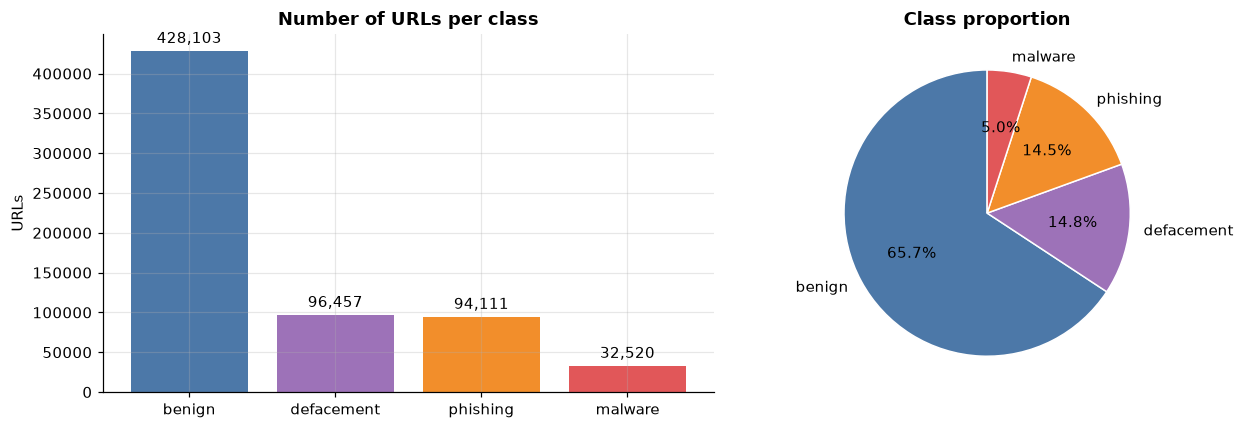

In [4]:
class_counts = raw["type"].value_counts().reindex(LABELS)
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
bars = ax[0].bar(class_counts.index, class_counts.values, color=[COLORS[c] for c in LABELS])
ax[0].bar_label(bars, labels=[f"{v:,}" for v in class_counts.values], padding=3)
ax[0].set_title("Number of URLs per class"); ax[0].set_ylabel("URLs")
ax[1].pie(class_counts.values, labels=LABELS, autopct="%1.1f%%", startangle=90,
          colors=[COLORS[c] for c in LABELS], wedgeprops={"edgecolor": "white"})
ax[1].set_title("Class proportion")
plt.tight_layout(); plt.show()

**📊 ผลลัพธ์:** ข้อมูลไม่สมดุล (**Imbalanced**) — `benign` มีประมาณ 66% ส่วน `malware` มีเพียงประมาณ 5%
ถ้าวัดผลด้วย Accuracy อย่างเดียว โมเดลที่ทายว่า "benign" ทุกครั้งก็ได้ Accuracy ~66% แล้ว
จึงต้องใช้ **Macro F1** และ **Recall รายคลาส** เป็นเกณฑ์หลัก และใช้ `class_weight="balanced"` ตอนฝึก

---
# 3. Data Preprocessing

ขั้นตอนทั้งหมดในส่วนนี้:

| # | ขั้นตอน | วิธีที่ใช้ |
|---|---|---|
| 3.1 | Missing Value | ตรวจ `isna()` |
| 3.2 | Duplicate & Label Conflict | ลบแถวซ้ำ และลบ URL ที่มีหลาย label |
| 3.3 | ข้อความเสียหาย | ตัดช่องว่างหัวท้าย ลบ control characters |
| 3.4 | สำรวจข้อมูล (EDA) | ความยาว URL แยกตามคลาส |
| 3.5 | Train/Test Split | แบ่ง 80:20 แบบแยก hostname (ป้องกัน data leakage) |
| 3.6 | Feature Extraction / Encoding | Character TF-IDF + Lexical features 27 ตัว |
| 3.7 | Feature Selection | TF-IDF เหลือ 20,000 n-grams (χ²) · Lexical เหลือ 22 ตัว (ANOVA F-test) |
| 3.8 | Scaling | MaxAbsScaler |
| 3.9 | Imbalanced Data | `class_weight="balanced"` |

## 3.1 Missing Value

In [5]:
missing = pd.DataFrame({"dtype": raw.dtypes.astype(str),
                        "missing": raw.isna().sum(),
                        "empty_string": (raw.astype(str).apply(lambda s: s.str.strip().eq(""))).sum()})
missing

,dtype,missing,empty_string
url,str,0,0
type,str,0,0


**📊 ผลลัพธ์:** ไม่มี Missing Value และไม่มีข้อความว่าง จึง **ไม่ต้องทำ imputation**

## 3.2 Duplicate และ Label Conflict
- **Exact duplicate** = URL และ label เหมือนกันทุกตัวอักษร → เก็บไว้แถวเดียว (ถ้าไม่ลบ URL เดียวกันอาจอยู่ทั้งใน Train และ Test ทำให้คะแนนสูงเกินจริง)
- **Label conflict** = URL เดียวกันแต่มี label ต่างกัน → ลบทุกแถวของ URL นั้น เพราะไม่รู้ว่า label ไหนถูก

## 3.3 ข้อความเสียหาย
- ตัดช่องว่างหัว/ท้าย (`strip`) และแปลง label เป็นตัวพิมพ์เล็ก
- ลบ URL ที่มี **control characters** (เช่น `\x00`, `\x07`) ซึ่งไม่ใช่ URL ที่พิมพ์ได้จริง

ตัวอย่าง URL ที่มี label ขัดแย้งกัน:


,url,type
328665,ebookstore[.]sony[.]com/reader/,benign
616942,ebookstore[.]sony[.]com/reader/,phishing
259609,en[.]wikipedia[.]org/wiki/Desktop_publishing,benign
616832,en[.]wikipedia[.]org/wiki/Desktop_publishing,phishing
213051,en[.]wikipedia[.]org/wiki/E-book,benign
616866,en[.]wikipedia[.]org/wiki/E-book,phishing


,rows
raw_rows,651191
exact_duplicates,10066
label_conflict_rows,12
control_char_rows,102
clean_rows,641011


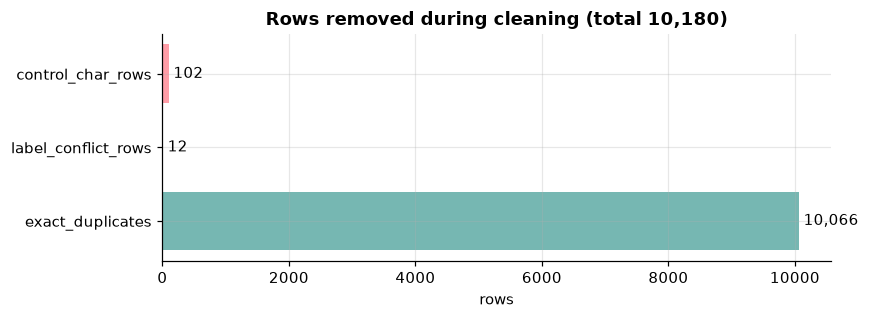

In [6]:
CONTROL_PATTERN = r"[\x00-\x1F\x7F-\x9F]"
audit = {"raw_rows": len(raw)}

df = raw[["url", "type"]].copy()
df["url"] = df["url"].astype(str).str.strip()
df["type"] = df["type"].astype(str).str.strip().str.lower()

# 3.2 Exact duplicates
audit["exact_duplicates"] = int(df.duplicated(["url", "type"]).sum())
df = df.drop_duplicates(["url", "type"])

# 3.2 Label conflicts
n_labels = df.groupby("url")["type"].transform("nunique")
audit["label_conflict_rows"] = int((n_labels > 1).sum())
print("ตัวอย่าง URL ที่มี label ขัดแย้งกัน:")
display(df[n_labels > 1].sort_values("url").head(6).assign(url=lambda d: d.url.map(defang)))
df = df[n_labels == 1]

# 3.3 Control characters
has_control = df["url"].str.contains(CONTROL_PATTERN, regex=True)
audit["control_char_rows"] = int(has_control.sum())
df = df[~has_control].reset_index(drop=True)
audit["clean_rows"] = len(df)

if QUICK_RUN:
    df = df.groupby("type", group_keys=False).sample(frac=100_000 / len(df), random_state=RANDOM_STATE).reset_index(drop=True)

audit_s = pd.Series(audit)
display(audit_s.to_frame("rows"))

fig, ax = plt.subplots(figsize=(8, 3))
removed = audit_s[["exact_duplicates", "label_conflict_rows", "control_char_rows"]]
bars = ax.barh(removed.index, removed.values, color=["#76B7B2", "#EDC948", "#FF9DA7"])
ax.bar_label(bars, labels=[f"{v:,}" for v in removed.values], padding=3)
ax.set_title(f"Rows removed during cleaning (total {removed.sum():,})"); ax.set_xlabel("rows")
plt.tight_layout(); plt.show()

**📊 ผลลัพธ์:** ลบ exact duplicate ~10,066 แถว, label conflict 12 แถว และ control characters ~102 แถว
เหลือข้อมูลสะอาด **641,011 แถว** (ลดลงเพียง ~1.6%)

## 3.4 สำรวจข้อมูล (EDA): ความยาว URL แยกตามคลาส

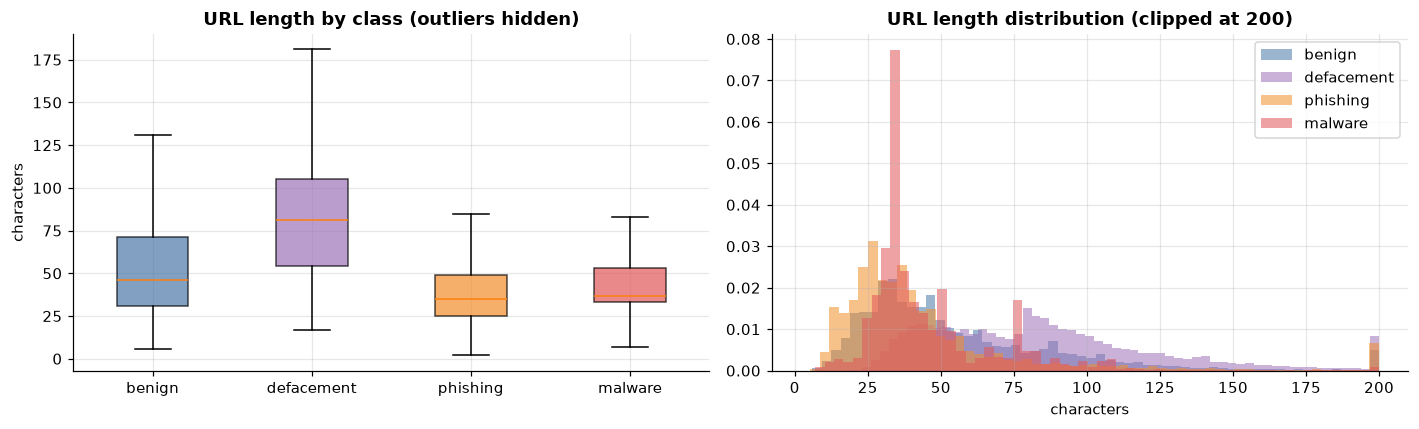

,mean,50%,min,max
type,,,,
benign,57.6754,46.0000,6.0000,2175.0000
defacement,86.1284,81.0000,17.0000,327.0000
phishing,45.7840,35.0000,2.0000,1779.0000
malware,46.6103,37.0000,7.0000,378.0000


In [7]:
df["url_length"] = df["url"].str.len()
fig, ax = plt.subplots(1, 2, figsize=(13, 4))
data = [df.loc[df.type == c, "url_length"] for c in LABELS]
bp = ax[0].boxplot(data, tick_labels=LABELS, showfliers=False, patch_artist=True)
for patch, c in zip(bp["boxes"], LABELS):
    patch.set_facecolor(COLORS[c]); patch.set_alpha(0.7)
ax[0].set_title("URL length by class (outliers hidden)"); ax[0].set_ylabel("characters")
for c in LABELS:
    ax[1].hist(df.loc[df.type == c, "url_length"].clip(upper=200), bins=60, alpha=0.55,
               label=c, color=COLORS[c], density=True)
ax[1].set_title("URL length distribution (clipped at 200)"); ax[1].set_xlabel("characters"); ax[1].legend()
plt.tight_layout(); plt.show()
df.groupby("type")["url_length"].describe().reindex(LABELS)[["mean", "50%", "min", "max"]]

**📊 ผลลัพธ์:** `defacement` ยาวที่สุด (median 81 ตัวอักษร เพราะมี path/query ยาวของ CMS เช่น `index.php?option=...`)
ส่วน `phishing` และ `malware` สั้นที่สุด (median ~35–37) ความยาวจึงเป็นสัญญาณที่มีประโยชน์ แต่กราฟซ้อนทับกันมาก
ใช้ความยาวอย่างเดียวแยกคลาสไม่ได้ ต้องใช้ features อื่นร่วมด้วย

### รูปแบบการเขียน URL แยกตามคลาส (มี `http(s)://` / `www.` หรือไม่)

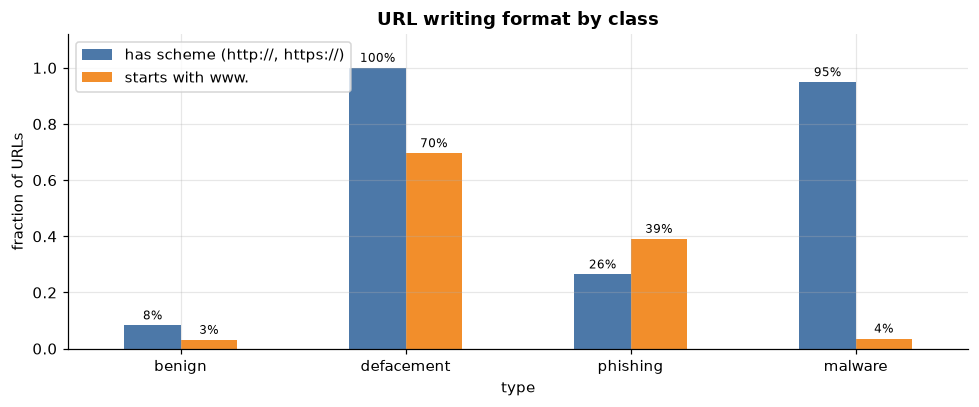

In [8]:
fmt = pd.DataFrame({
    "has scheme (http://, https://)": df["url"].str.match(r"^[A-Za-z][A-Za-z0-9+.-]*://"),
    "starts with www.": df["url"].str.contains(r"^(?:[A-Za-z]+://)?www\d?\.", case=False, regex=True),
}).groupby(df["type"]).mean().reindex(LABELS)
ax = fmt.plot.bar(figsize=(9, 3.8), rot=0, color=["#4C78A8", "#F28E2B"])
for c in ax.containers:
    ax.bar_label(c, labels=[f"{v*100:.0f}%" for v in c.datavalues], fontsize=8, padding=2)
ax.set_ylim(0, 1.12); ax.set_ylabel("fraction of URLs"); ax.set_title("URL writing format by class")
plt.tight_layout(); plt.show()

**📊 ผลลัพธ์ (สำคัญ):** รูปแบบการเขียน URL ต่างกันมากตาม **แหล่งที่เก็บข้อมูล** ไม่ใช่ตามความอันตราย —
`defacement` มี `http://` **100%**, `malware` ~95% แต่ `benign` มีเพียง ~8% ส่วน `www.` พบใน phishing ~39% แต่ benign เพียง ~3%
โมเดลจึงอาจเรียนรู้ "ทางลัด" นี้ได้ (เช่น เห็น `https://www.` แล้วคิดว่าอันตราย) — จะตรวจผลกระทบในหัวข้อ 5.6 และอภิปรายในหัวข้อ 7

**Outlier:** URL ยาวมาก (สูงสุด ~2,000 ตัวอักษร) **ไม่ลบทิ้ง** เพราะ URL ยาวผิดปกติเป็นลักษณะหนึ่งของ URL อันตราย

## 3.5 Train/Test Split (ทำก่อนสร้าง features เพื่อไม่ให้ข้อมูล Test รั่วเข้าการ fit)
ถ้าสุ่มแบ่งธรรมดา URL หลายรายการจากเว็บเดียวกัน (hostname เดียวกัน) จะไปอยู่ทั้ง Train และ Test
โมเดลจะ "จำชื่อเว็บ" แทนการเรียนรูปแบบ → คะแนนสูงเกินจริง (**data leakage**)
จึงใช้ **StratifiedGroupKFold** โดยให้ `group = hostname` และรักษาสัดส่วนคลาสใกล้เดิม แล้วใช้ 1 fold เป็น Test (≈20%)

Train: 512,808 แถว (80.0%)  |  Test: 128,203 แถว (20.0%)


hostname ที่ซ้ำกันระหว่าง Train/Test: 0


URL ที่ซ้ำกันระหว่าง Train/Test: 0


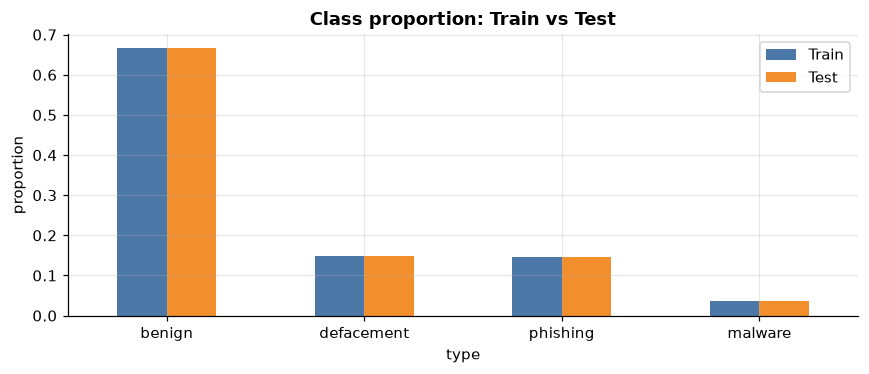

In [9]:
from urllib.parse import urlsplit
def get_host(u):
    try:
        return (urlsplit(u if re.match(r"^[A-Za-z][A-Za-z0-9+.-]*://", u) else "http://" + u).hostname or "").lower()
    except ValueError:
        return ""
df["host"] = df["url"].map(get_host)
groups = df["host"].where(df["host"] != "", "row_" + df.index.astype(str))

sgkf = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
train_idx, test_idx = next(sgkf.split(df["url"], df["type"], groups))
train, test = df.iloc[train_idx].reset_index(drop=True), df.iloc[test_idx].reset_index(drop=True)
X_train_text, y_train = train["url"].to_numpy(dtype=object), train["type"].to_numpy()
X_test_text,  y_test  = test["url"].to_numpy(dtype=object),  test["type"].to_numpy()

print(f"Train: {len(train):,} แถว ({len(train)/len(df):.1%})  |  Test: {len(test):,} แถว ({len(test)/len(df):.1%})")
print(f"hostname ที่ซ้ำกันระหว่าง Train/Test: {len(set(train.host) & set(test.host) - {''})}")
print(f"URL ที่ซ้ำกันระหว่าง Train/Test: {len(set(train.url) & set(test.url))}")

prop = pd.DataFrame({"Train": train.type.value_counts(normalize=True),
                     "Test": test.type.value_counts(normalize=True)}).reindex(LABELS)
ax = prop.plot.bar(figsize=(8, 3.5), color=["#4C78A8", "#F28E2B"], rot=0)
ax.set_title("Class proportion: Train vs Test"); ax.set_ylabel("proportion")
plt.tight_layout(); plt.show()

**📊 ผลลัพธ์:** ได้ Train ≈ 80% / Test ≈ 20% สัดส่วนคลาสสองชุดใกล้กันมาก และ **hostname/URL ซ้ำกันระหว่าง Train–Test = 0**

## 3.6 Feature Extraction / Encoding
URL เป็น **ข้อความ** โมเดลต้องการตัวเลข จึงแปลงเป็น 2 กลุ่ม features:

**(A) Character TF-IDF** — ตัด URL เป็นชิ้นตัวอักษรยาว 3–5 ตัว (char n-grams) เช่น `paypal-login` → `pay`, `ayp`, `ypa`, ..., `login`
แล้วให้น้ำหนักด้วย TF-IDF (ชิ้นที่พบบ่อยในบาง URL แต่ไม่พบทั่วไปจะมีน้ำหนักสูง) สร้าง vocabulary เริ่มต้น 50,000 n-grams แล้วคัดเลือกต่อในหัวข้อ 3.7

**(B) Lexical features 27 ตัว** — ตัวเลขที่สรุปโครงสร้างของ URL เช่น ความยาว, จำนวนตัวเลข, จำนวนจุด, มี IP แทนชื่อโดเมนไหม, มีคำว่า login/verify ไหม, entropy

Target (`type`) เป็นข้อความ 4 ค่า — scikit-learn classifiers รับ label เป็น string ได้โดยตรงและ encode ภายในให้
(ยกเว้น XGBoost ที่ต้องแปลงเป็นเลข 0–3 ก่อน แล้วแปลงกลับเป็นชื่อคลาสหลังทำนาย)

โค้ดสร้าง lexical features เขียนเป็นไฟล์ `url_features.py` เพื่อให้ **Notebook และ Web App ใช้โค้ดเดียวกัน**:

In [10]:
%%writefile url_features.py
"""แปลงข้อความ URL เป็น lexical features 27 ตัว (ใช้ร่วมกันทั้ง Notebook และ Web App)

ฟังก์ชันในไฟล์นี้อ่านเฉพาะ "ข้อความ" ของ URL เท่านั้น ไม่มีการเปิดเว็บไซต์หรือค้น DNS
"""
from __future__ import annotations

import ipaddress
import math
import re
from collections import Counter
from urllib.parse import urlsplit

import numpy as np

SCHEME_PATTERN = r"^[A-Za-z][A-Za-z0-9+.-]*://"
CONTROL_PATTERN = r"[\x00-\x1F\x7F-\x9F]"

SUSPICIOUS_WORDS = (
    "login", "signin", "verify", "secure", "account", "update", "bank",
    "password", "confirm", "wallet", "paypal", "invoice", "webscr",
)
SHORTENERS = {
    "bit.ly", "tinyurl.com", "t.co", "goo.gl", "ow.ly", "is.gd",
    "buff.ly", "adf.ly", "cutt.ly", "tiny.cc",
}

FEATURE_NAMES = [
    "url_length", "host_length", "path_length", "query_length", "fragment_length",
    "subdomain_count", "path_depth", "query_param_count", "digit_count", "alpha_count",
    "special_count", "dot_count", "hyphen_count", "slash_count", "at_count", "percent_count",
    "equals_count", "underscore_count", "is_https", "host_is_ip", "has_port", "punycode",
    "non_ascii", "known_shortener", "suspicious_word", "entropy", "host_digit_count",
]


def url_entropy(value: str) -> float:
    """Shannon entropy ของตัวอักษรใน URL (URL ที่สุ่มตัวอักษรมักมีค่าสูง)"""
    if not value:
        return 0.0
    counts = Counter(value)
    n = len(value)
    return float(-sum((c / n) * math.log2(c / n) for c in counts.values()))


def extract_one_url(value: str) -> list[float]:
    """แปลง URL 1 รายการเป็นตัวเลข 27 ค่า ตามลำดับใน FEATURE_NAMES"""
    raw = str(value)
    # เติม http:// เฉพาะตอน parse เพื่อแยก host/path ได้ ข้อความต้นฉบับไม่ถูกแก้
    parse_value = raw if re.match(SCHEME_PATTERN, raw) else f"http://{raw}"
    try:
        parts = urlsplit(parse_value)
        host = (parts.hostname or "").lower()
        port = parts.port
    except ValueError:
        parts, host, port = urlsplit(""), "", None
    try:
        ipaddress.ip_address(host)
        host_is_ip = 1
    except ValueError:
        host_is_ip = 0
    host_parts = [p for p in host.split(".") if p]
    lower = raw.lower()
    return [
        len(raw), len(host), len(parts.path), len(parts.query), len(parts.fragment),
        max(0, len(host_parts) - 2),
        sum(bool(p) for p in parts.path.split("/")),
        len([p for p in parts.query.split("&") if p]),
        sum(c.isdigit() for c in raw), sum(c.isalpha() for c in raw),
        sum(not c.isalnum() for c in raw), raw.count("."), raw.count("-"),
        raw.count("/"), raw.count("@"), raw.count("%"), raw.count("="), raw.count("_"),
        int(parts.scheme.lower() == "https"), host_is_ip, int(port is not None),
        int("xn--" in host), int(any(ord(c) > 127 for c in raw)),
        int(host in SHORTENERS), int(any(w in lower for w in SUSPICIOUS_WORDS)),
        url_entropy(raw), sum(c.isdigit() for c in host),
    ]


def extract_lexical_features(values, keep=None) -> np.ndarray:
    """แปลงรายการ URL เป็น matrix (n, 27) ใช้กับ sklearn FunctionTransformer

    keep = รายการ index ของ features ที่เลือกไว้ (Feature Selection) ถ้าไม่ระบุจะคืนครบ 27 ตัว
    """
    X = np.asarray(
        [extract_one_url(v) for v in np.asarray(values, dtype=object).ravel()],
        dtype=np.float32,
    )
    return X if keep is None else X[:, list(keep)]


def prepare_single_url(value: str) -> str:
    """ตรวจ input ของ Web App ด้วยกฎเดียวกับตอนทำความสะอาดข้อมูล"""
    if not isinstance(value, str):
        raise ValueError("กรุณากรอก URL เป็นข้อความ")
    cleaned = value.strip()
    if not cleaned:
        raise ValueError("กรุณากรอก URL ก่อนกด Predict")
    if re.search(CONTROL_PATTERN, cleaned):
        raise ValueError("URL มีอักขระควบคุม (control character) จึงไม่สามารถทำนายได้")
    return cleaned

Overwriting url_features.py


In [11]:
from url_features import extract_lexical_features, FEATURE_NAMES, prepare_single_url

example = ["google.com", "http://paypal.com.secure-login.verify-account.xyz/signin?id=123",
           "http://192.168.10.5/files/setup.exe"]
pd.DataFrame(extract_lexical_features(example), columns=FEATURE_NAMES,
             index=[defang(u, 45) for u in example])

,url_length,host_length,path_length,query_length,fragment_length,subdomain_count,path_depth,query_param_count,digit_count,alpha_count,...,underscore_count,is_https,host_is_ip,has_port,punycode,non_ascii,known_shortener,suspicious_word,entropy,host_digit_count
google[.]com,10.0000,10.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,9.0000,...,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,2.6464,0.0000
hxxp://paypal[.]com[.]secure-login[.]verify-account,63.0000,42.0000,7.0000,6.0000,0.0000,3.0000,1.0000,1.0000,3.0000,48.0000,...,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,1.0000,4.6933,0.0000
hxxp://192[.]168[.]10[.]5/files/setup[.]exe,35.0000,12.0000,16.0000,0.0000,0.0000,2.0000,2.0000,0.0000,9.0000,17.0000,...,0.0000,0.0000,1.0000,0.0000,0.0000,0.0000,0.0000,0.0000,4.0576,9.0000


**📊 ผลลัพธ์:** URL ปลอมตัวอย่างมีความยาว จำนวนจุด/ขีด และ `suspicious_word = 1` สูงกว่า `google.com` อย่างชัดเจน
ส่วน URL ที่ใช้ IP ตรงได้ `host_is_ip = 1`

### สร้าง Features จาก Train แล้วนำไปแปลง Test
`fit` **บน Train เท่านั้น** แล้วค่อย `transform` Test (ป้องกันข้อมูล Test รั่วเข้า vocabulary)

In [12]:
TFIDF_PARAMS = dict(analyzer="char", ngram_range=(3, 5), min_df=5, max_features=50_000,
                    sublinear_tf=True, lowercase=False, dtype=np.float32)
t0 = time.perf_counter()
tfidf = TfidfVectorizer(**TFIDF_PARAMS)
Xtr_tfidf_all = tfidf.fit_transform(X_train_text)
Xte_tfidf_all = tfidf.transform(X_test_text)
print(f"TF-IDF: {Xtr_tfidf_all.shape[1]:,} n-grams  ({time.perf_counter()-t0:.0f} s)")

t0 = time.perf_counter()
LEX_ALL = extract_lexical_features(df["url"].to_numpy(dtype=object))   # 27 features ของทุกแถว (คำนวณครั้งเดียว)
Xtr_lex_raw, Xte_lex_raw = LEX_ALL[train_idx], LEX_ALL[test_idx]
print(f"Lexical: {LEX_ALL.shape[1]} features  ({time.perf_counter()-t0:.0f} s)")

TF-IDF: 50,000 n-grams  (97 s)


Lexical: 27 features  (28 s)


## 3.7 Feature Selection
คัดเลือก features เพื่อ **ตัด noise และลดขนาดโมเดล** โดยคำนวณจาก Train เท่านั้น

**(A) Lexical features: ตัด 5 ตัวที่แยกคลาสได้น้อยที่สุด** — วัดด้วย **ANOVA F-test** (`f_classif`) แล้วตัด 5 ตัวที่ F-score ต่ำสุด (แถบสีแดง) ทิ้ง → เหลือ **22 ตัว**

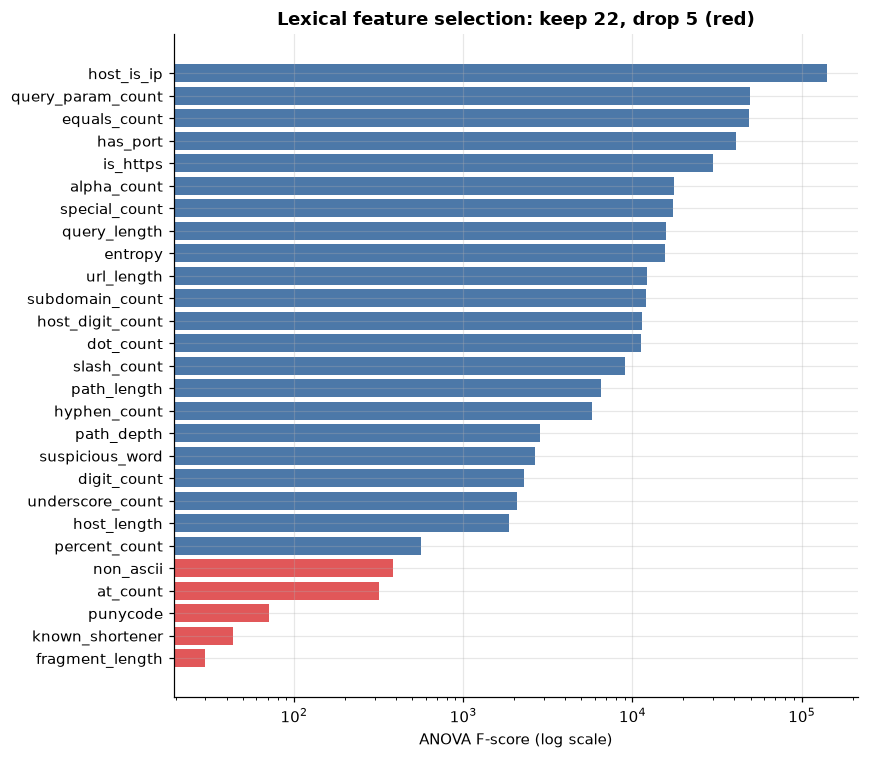

ตัดทิ้ง: ['fragment_length', 'known_shortener', 'punycode', 'at_count', 'non_ascii']


In [13]:
N_DROP_LEXICAL = 5
F, _ = f_classif(Xtr_lex_raw, y_train)
fscore = pd.Series(np.nan_to_num(F), index=FEATURE_NAMES).sort_values()
DROPPED = list(fscore.index[:N_DROP_LEXICAL])
KEEP_IDX = [i for i, n in enumerate(FEATURE_NAMES) if n not in DROPPED]
KEPT_NAMES = [FEATURE_NAMES[i] for i in KEEP_IDX]

fig, ax = plt.subplots(figsize=(8, 7))
ax.barh(fscore.index, fscore.values, color=["#E15759" if n in DROPPED else "#4C78A8" for n in fscore.index])
ax.set_xscale("log"); ax.set_xlabel("ANOVA F-score (log scale)")
ax.set_title(f"Lexical feature selection: keep {len(KEEP_IDX)}, drop {len(DROPPED)} (red)")
plt.tight_layout(); plt.show()
print("ตัดทิ้ง:", DROPPED)

**📊 ผลลัพธ์:** features ที่ถูกตัดคือ `fragment_length`, `known_shortener`, `punycode`, `at_count`, `non_ascii`
ทั้ง 5 ตัวแทบไม่เคยมีค่าใน Dataset (URL เกือบทั้งหมดมีค่า 0) จึงไม่ช่วยแยกคลาส ส่วนตัวที่แยกคลาสได้ดีที่สุดคือ `host_is_ip`, `query_param_count`, `equals_count`

**(B) TF-IDF: เก็บ 20,000 n-grams ที่แยกคลาสได้ดีที่สุด** — จาก 50,000 n-grams ใช้ **Chi-square (χ²)** วัดความสัมพันธ์ระหว่าง n-gram กับคลาส
แล้วเก็บ 20,000 ตัวที่คะแนนสูงสุด (`SelectKBest(chi2, k=20000)`) ตัดทิ้ง 30,000 ตัวที่เป็น noise
ค่า k = 20,000 เลือกจากการทดลองบน Validation ที่แยกจาก Test

TF-IDF: 50,000 → 20,000 n-grams   |   Lexical: 27 → 22 features


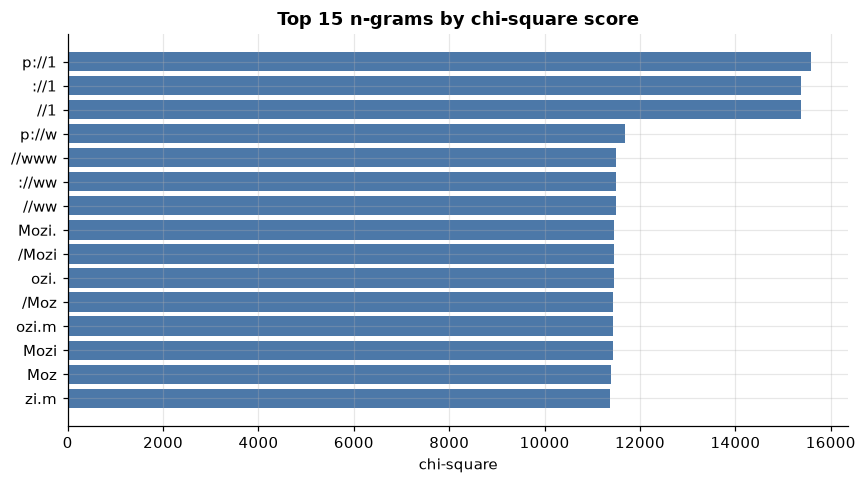

In [14]:
N_NGRAMS = 20_000
selector = SelectKBest(chi2, k=min(N_NGRAMS, Xtr_tfidf_all.shape[1])).fit(Xtr_tfidf_all, y_train)
Xtr_T, Xte_T = selector.transform(Xtr_tfidf_all), selector.transform(Xte_tfidf_all)
Xtr_L_raw, Xte_L_raw = Xtr_lex_raw[:, KEEP_IDX], Xte_lex_raw[:, KEEP_IDX]
print(f"TF-IDF: {Xtr_tfidf_all.shape[1]:,} → {Xtr_T.shape[1]:,} n-grams   |   Lexical: {len(FEATURE_NAMES)} → {len(KEEP_IDX)} features")

vocab_all = tfidf.get_feature_names_out()
top = np.argsort(np.nan_to_num(selector.scores_))[::-1][:15]
fig, ax = plt.subplots(figsize=(8, 4.5))
ax.barh([repr(v)[1:-1] for v in vocab_all[top]][::-1], selector.scores_[top][::-1], color="#4C78A8")
ax.set_title("Top 15 n-grams by chi-square score"); ax.set_xlabel("chi-square")
plt.tight_layout(); plt.show()

**📊 ผลลัพธ์:** n-grams ที่ χ² สูงสุดได้แก่ `://1` (URL ที่ใช้ IP แทนชื่อโดเมน เช่น `http://1xx.xx...` พบบ่อยใน malware),
`//www` (รูปแบบการเขียน URL ที่ผูกกับบางคลาส — dataset bias ในหัวข้อ 3.4) และ `Mozi` (ชื่อไฟล์ของมัลแวร์ botnet *Mozi* ที่พบซ้ำจำนวนมากในคลาส malware)

## 3.8 Scaling
Lexical features มีช่วงค่าต่างกันมาก (เช่น `url_length` หลักร้อย แต่ `is_https` เป็น 0/1) ทำให้โมเดลที่ใช้ระยะทาง/น้ำหนัก (KNN, SVM, Logistic)
ให้ความสำคัญกับ feature ที่ค่าใหญ่เกินจริง จึงใช้ **MaxAbsScaler** (หารด้วยค่าสัมบูรณ์สูงสุดของแต่ละคอลัมน์ → อยู่ในช่วง [0, 1])
เลือก MaxAbsScaler แทน StandardScaler เพราะ **ไม่ทำลายความเป็น sparse** จึงนำไปต่อกับ TF-IDF ได้ (TF-IDF ถูก normalize ด้วย L2 อยู่แล้ว)

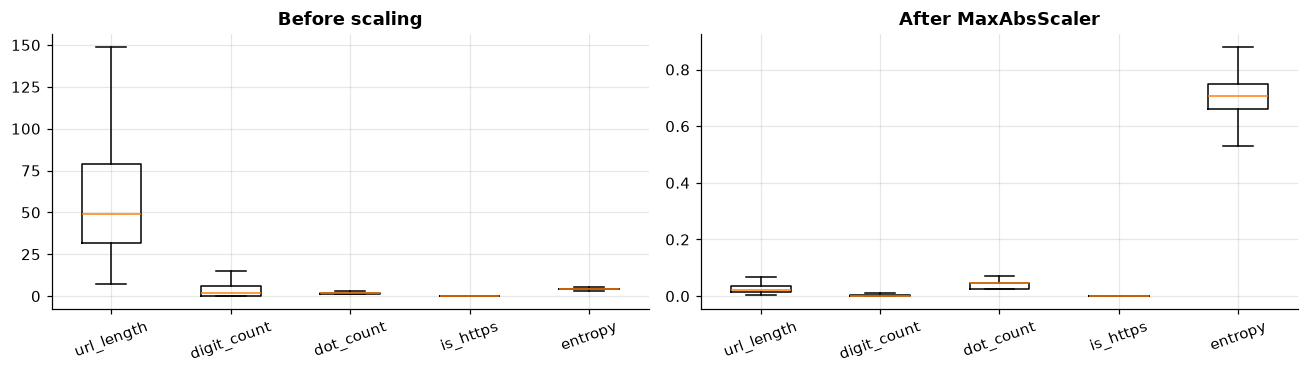

In [15]:
scaler = MaxAbsScaler().fit(Xtr_L_raw)          # fit บน Train เท่านั้น
Xtr_L, Xte_L = scaler.transform(Xtr_L_raw), scaler.transform(Xte_L_raw)

cols = ["url_length", "digit_count", "dot_count", "is_https", "entropy"]
idx = [KEPT_NAMES.index(c) for c in cols]
fig, ax = plt.subplots(1, 2, figsize=(12, 3.5))
ax[0].boxplot(Xtr_L_raw[:20000, idx], tick_labels=cols, showfliers=False); ax[0].set_title("Before scaling")
ax[1].boxplot(Xtr_L[:20000, idx], tick_labels=cols, showfliers=False); ax[1].set_title("After MaxAbsScaler")
for a in ax: a.tick_params(axis="x", rotation=20)
plt.tight_layout(); plt.show()

**📊 ผลลัพธ์:** หลัง scaling ทุก feature อยู่ในช่วง 0–1 แล้ว แต่ `url_length` ถูกบีบใกล้ 0 เพราะมี URL ยาวมาก (~2,000 ตัวอักษร) เป็นค่าสูงสุด
นี่คือข้อจำกัดของ MaxAbsScaler ที่ไวต่อ outlier เราเลือกใช้เพราะรักษา sparse matrix ไว้ได้เพื่อต่อกับ TF-IDF
(`is_https` เป็นเส้นแบนที่ 0 เพราะ URL ส่วนใหญ่ไม่มี https)

## 3.9 Imbalanced Data
ใช้ **cost-sensitive learning**: `class_weight="balanced"` ให้น้ำหนักความผิดพลาดของแต่ละคลาส = `n_samples / (n_classes × n_class)`
คลาสที่มีน้อย (malware) จึงมีน้ำหนักมากขึ้น โดยไม่ต้องสร้างข้อมูลสังเคราะห์ และ **ไม่แตะสัดส่วนของ Test**

In [16]:
from sklearn.utils.class_weight import compute_class_weight
w = compute_class_weight("balanced", classes=np.array(LABELS), y=y_train)
pd.DataFrame({"train_rows": pd.Series(y_train).value_counts().reindex(LABELS).values, "class_weight": w}, index=LABELS)

,train_rows,class_weight
benign,342456,0.3744
defacement,76246,1.6814
phishing,75190,1.7050
malware,18916,6.7774


**📊 ผลลัพธ์:** malware ได้น้ำหนัก ~6.8 ขณะที่ benign ได้ ~0.37 (ต่างกัน ~18 เท่า) → โมเดลถูกลงโทษหนักขึ้นมากเมื่อทาย malware ผิด

---
# 4. Machine Learning Models

เปรียบเทียบ **11 โมเดล แบ่งเป็น 3 กลุ่มตาม Input** ทุกโมเดลรับ URL แถวเดียวกันและทำนาย y เหมือนกัน ต่างกันที่วิธีแปลง URL เป็นตัวเลข

| กลุ่ม Input | โมเดล | Input ของโมเดล | เหตุผล |
|---|---|---|---|
| **TF-IDF** | ComplementNB, Logistic Regression, LinearSVC | char n-grams 20,000 มิติ (sparse) | โมเดลเชิงเส้น/NB ทำงานดีกับข้อความมิติสูง |
| **Lexical** | KNN, Decision Tree, Random Forest, XGBoost, LightGBM, CatBoost | ตัวเลข 22 ค่า | โมเดล tree/ระยะทางเหมาะกับ features จำนวนน้อย (ช้ามากกับ TF-IDF 20,000 มิติ) |
| **Hybrid** | Hybrid LinearSVC, Hybrid Logistic Regression | TF-IDF + Lexical ต่อกัน | รวมสัญญาณ "ชิ้นข้อความ" + "โครงสร้าง URL" |

และมี **Dummy (majority class)** ที่ทาย benign ทุกครั้งเป็น Baseline

### ขั้นตอนการคัดเลือกโมเดล
```
Train (80%) ──┬── Development Train ─→ ฝึก 11 โมเดล × hyperparameters หลายค่า
              └── Validation         ─→ วัด Macro F1 → เลือกค่าที่ดีที่สุด + ผู้ชนะของแต่ละกลุ่ม
                                              ↓
Train เต็ม ─→ ฝึกผู้ชนะ 3 กลุ่มใหม่ ─→ วัดผลบน Test (20%) ครั้งเดียว
```
**Test ไม่ถูกใช้ในการเลือกโมเดลหรือ hyperparameter เลย** จึงเป็นการวัดผลที่เป็นธรรม

## 4.1 แบ่ง Development Train / Validation จาก Train
แบ่งตาม hostname อีกครั้ง (StratifiedGroupKFold) แล้วสุ่มแบบรักษาสัดส่วนคลาส ให้ทุกโมเดลใช้ข้อมูลชุดเดียวกัน

In [17]:
DEV_ROWS, VAL_ROWS = 100_000, 25_000
inner = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=2026)
dev_i, val_i = next(inner.split(train["url"], train["type"], groups.iloc[train_idx]))
dev_i = train_test_split(dev_i, train_size=min(DEV_ROWS, len(dev_i) - 1), stratify=y_train[dev_i], random_state=RANDOM_STATE)[0]
val_i = train_test_split(val_i, train_size=min(VAL_ROWS, len(val_i) - 1), stratify=y_train[val_i], random_state=RANDOM_STATE)[0]
assert not set(train.host.iloc[dev_i]) & set(train.host.iloc[val_i]) - {""}
y_dev, y_val = y_train[dev_i], y_train[val_i]

# สร้าง features ใหม่จาก Development Train เท่านั้น (ขั้นตอนเดียวกับหัวข้อ 3.6–3.8)
tf_dev = TfidfVectorizer(**TFIDF_PARAMS).fit(X_train_text[dev_i])
T_dev_all, T_val_all = tf_dev.transform(X_train_text[dev_i]), tf_dev.transform(X_train_text[val_i])
sel_dev = SelectKBest(chi2, k=min(N_NGRAMS, T_dev_all.shape[1])).fit(T_dev_all, y_dev)
sc_dev = MaxAbsScaler().fit(Xtr_L_raw[dev_i])
FEATS_DEV = (sel_dev.transform(T_dev_all), sc_dev.transform(Xtr_L_raw[dev_i]))
FEATS_VAL = (sel_dev.transform(T_val_all), sc_dev.transform(Xtr_L_raw[val_i]))
print(f"Development Train: {len(dev_i):,} แถว  |  Validation: {len(val_i):,} แถว  |  hostname ซ้ำกัน = 0")

Development Train: 100,000 แถว  |  Validation: 25,000 แถว  |  hostname ซ้ำกัน = 0


## 4.2 กำหนด 11 โมเดลและ Hyperparameters ที่ทดลอง
ทุกโมเดลที่รองรับใช้ `class_weight="balanced"` (XGBoost ใช้ `sample_weight` แบบ balanced แทน; ComplementNB และ KNN ไม่มีตัวเลือกนี้)
แต่ละโมเดลลอง hyperparameter 2–3 ค่า แล้วเลือกค่าที่ได้ Macro F1 บน Validation สูงสุด

In [18]:
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier
RS = RANDOM_STATE
CANDIDATES = [
    # (กลุ่ม, ชื่อ, สร้างโมเดลจาก params, grid ของ hyperparameter, น้ำหนัก lexical ใน Hybrid)
    ("TF-IDF", "ComplementNB", lambda p: ComplementNB(**p), {"alpha": [0.1, 1.0]}, None),
    ("TF-IDF", "LogisticRegression", lambda p: LogisticRegression(class_weight="balanced", max_iter=300, random_state=RS, **p), {"C": [1, 10]}, None),
    ("TF-IDF", "LinearSVC", lambda p: LinearSVC(class_weight="balanced", max_iter=5000, random_state=RS, **p), {"C": [0.3, 1, 3]}, None),
    ("Lexical", "KNN", lambda p: KNeighborsClassifier(weights="distance", algorithm="brute", n_jobs=-1, **p), {"n_neighbors": [5, 15]}, None),
    ("Lexical", "DecisionTree", lambda p: DecisionTreeClassifier(class_weight="balanced", random_state=RS, **p), {"max_depth": [20, None]}, None),
    ("Lexical", "RandomForest", lambda p: RandomForestClassifier(n_estimators=100, class_weight="balanced_subsample", n_jobs=-1, random_state=RS, **p), {"min_samples_leaf": [1, 3]}, None),
    ("Lexical", "XGBoost", lambda p: XGBClassifier(n_estimators=250, learning_rate=0.1, subsample=0.8, colsample_bytree=0.8, tree_method="hist", n_jobs=-1, random_state=RS, verbosity=0, **p), {"max_depth": [6, 10]}, None),
    ("Lexical", "LightGBM", lambda p: LGBMClassifier(n_estimators=250, learning_rate=0.1, class_weight="balanced", n_jobs=-1, random_state=RS, verbosity=-1, **p), {"num_leaves": [31, 127]}, None),
    ("Lexical", "CatBoost", lambda p: CatBoostClassifier(iterations=250, learning_rate=0.1, auto_class_weights="Balanced", verbose=False, allow_writing_files=False, thread_count=-1, random_seed=RS, **p), {"depth": [6, 8]}, None),
    ("Hybrid", "Hybrid LinearSVC", lambda p: LinearSVC(class_weight="balanced", max_iter=5000, random_state=RS, **p), {"C": [0.3, 1, 3]}, 2.0),
    ("Hybrid", "Hybrid LogisticRegression", lambda p: LogisticRegression(class_weight="balanced", max_iter=300, random_state=RS, **p), {"C": [1, 10]}, 0.5),
]
GROUP_COLORS = {"TF-IDF": "#4C78A8", "Lexical": "#59A14F", "Hybrid": "#E15759"}

def make_X(group, feats, lexical_weight=None):
    T, L = feats
    if group == "TF-IDF":
        return T
    if group == "Lexical":
        return L
    return sparse.hstack([T, sparse.csr_matrix(L * lexical_weight)]).tocsr()

def fit_predict(model, Xa, ya, Xb):
    """ฝึกแล้วทำนาย คืนชื่อคลาส (XGBoost ต้องแปลง label เป็นเลขก่อน)"""
    if isinstance(model, XGBClassifier):
        code = {c: i for i, c in enumerate(LABELS)}
        model.fit(Xa, np.array([code[c] for c in ya]), sample_weight=compute_sample_weight("balanced", ya))
        return np.array(LABELS)[np.asarray(model.predict(Xb)).astype(int)]
    model.fit(Xa, ya)
    return np.asarray(model.predict(Xb)).ravel()

def scores(y_true, y_pred):
    return {"accuracy": accuracy_score(y_true, y_pred),
            "precision_macro": precision_score(y_true, y_pred, labels=LABELS, average="macro", zero_division=0),
            "recall_macro": recall_score(y_true, y_pred, labels=LABELS, average="macro", zero_division=0),
            "f1_macro": f1_score(y_true, y_pred, labels=LABELS, average="macro", zero_division=0)}

pd.DataFrame([{"กลุ่ม": g, "โมเดล": n, "hyperparameters ที่ลอง": grid} for g, n, _, grid, _ in CANDIDATES])

,กลุ่ม,โมเดล,hyperparameters ที่ลอง
0,TF-IDF,ComplementNB,"{'alpha': [0.1, 1.0]}"
1,TF-IDF,LogisticRegression,"{'C': [1, 10]}"
2,TF-IDF,LinearSVC,"{'C': [0.3, 1, 3]}"
3,Lexical,KNN,"{'n_neighbors': [5, 15]}"
4,Lexical,DecisionTree,"{'max_depth': [20, None]}"
5,Lexical,RandomForest,"{'min_samples_leaf': [1, 3]}"
6,Lexical,XGBoost,"{'max_depth': [6, 10]}"
7,Lexical,LightGBM,"{'num_leaves': [31, 127]}"
8,Lexical,CatBoost,"{'depth': [6, 8]}"
9,Hybrid,Hybrid LinearSVC,"{'C': [0.3, 1, 3]}"


## 4.3 ฝึก 11 โมเดลบน Development Train และวัดบน Validation

In [19]:
from sklearn.model_selection import ParameterGrid
screen_rows, val_pred = [], {}
for group, name, build, grid, w in CANDIDATES:
    Xa, Xb = make_X(group, FEATS_DEV, w), make_X(group, FEATS_VAL, w)
    best = None
    for params in ParameterGrid(grid):
        t0 = time.perf_counter()
        pred = fit_predict(build(params), Xa, y_dev, Xb)
        row = {"group": group, "model": name, "best_params": params, **scores(y_val, pred),
               "fit_predict_s": time.perf_counter() - t0}
        if best is None or row["f1_macro"] > best[0]["f1_macro"]:
            best = (row, pred)
    screen_rows.append(best[0]); val_pred[name] = best[1]
    print(f"✓ {group:<8} {name:<27} Macro F1 = {best[0]['f1_macro']:.4f}   {best[0]['best_params']}")

screening = pd.DataFrame(screen_rows).set_index("model").sort_values("f1_macro", ascending=False)
screening[["group", "best_params", "accuracy", "precision_macro", "recall_macro", "f1_macro", "fit_predict_s"]]

✓ TF-IDF   ComplementNB                Macro F1 = 0.7435   {'alpha': 1.0}


✓ TF-IDF   LogisticRegression          Macro F1 = 0.8817   {'C': 10}


✓ TF-IDF   LinearSVC                   Macro F1 = 0.8888   {'C': 1}


✓ Lexical  KNN                         Macro F1 = 0.8385   {'n_neighbors': 15}


✓ Lexical  DecisionTree                Macro F1 = 0.8093   {'max_depth': 20}


...

✓ Lexical  LightGBM                    Macro F1 = 0.8505   {'num_leaves': 127}


✓ Lexical  CatBoost                    Macro F1 = 0.8444   {'depth': 8}


✓ Hybrid   Hybrid LinearSVC            Macro F1 = 0.8913   {'C': 1}


✓ Hybrid   Hybrid LogisticRegression   Macro F1 = 0.8820   {'C': 10}


,group,best_params,accuracy,precision_macro,recall_macro,f1_macro,fit_predict_s
model,,,,,,,
Hybrid LinearSVC,Hybrid,{'C': 1},0.9422,0.9264,0.8676,0.8913,19.5706
LinearSVC,TF-IDF,{'C': 1},0.9375,0.9214,0.8668,0.8888,8.8679
Hybrid LogisticRegression,Hybrid,{'C': 10},0.9354,0.9008,0.8717,0.8820,9.0566
LogisticRegression,TF-IDF,{'C': 10},0.9306,0.9039,0.8701,0.8817,7.7587
RandomForest,Lexical,{'min_samples_leaf': 3},0.9125,0.8912,0.8339,0.8544,2.5896
LightGBM,Lexical,{'num_leaves': 127},0.9119,0.8755,0.8369,0.8505,6.7412
XGBoost,Lexical,{'max_depth': 10},0.9113,0.8679,0.8396,0.8490,6.9372
CatBoost,Lexical,{'depth': 8},0.9010,0.8495,0.8501,0.8444,15.9052
KNN,Lexical,{'n_neighbors': 15},0.9071,0.8801,0.8127,0.8385,3.4878


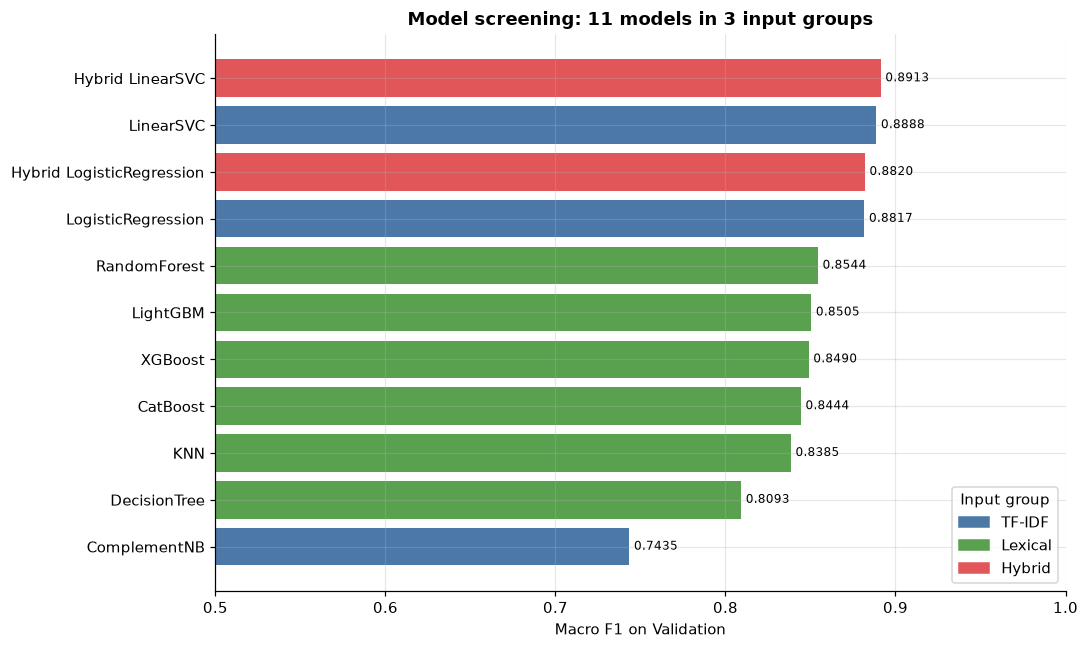

In [20]:
plot_df = screening.iloc[::-1]
fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh(plot_df.index, plot_df.f1_macro, color=[GROUP_COLORS[g] for g in plot_df.group])
ax.bar_label(bars, fmt="%.4f", padding=3, fontsize=8)
ax.set_xlim(0.5, 1.0); ax.set_xlabel("Macro F1 on Validation")
ax.set_title("Model screening: 11 models in 3 input groups")
from matplotlib.patches import Patch
ax.legend(handles=[Patch(color=c, label=g) for g, c in GROUP_COLORS.items()], title="Input group", loc="lower right")
plt.tight_layout(); plt.show()

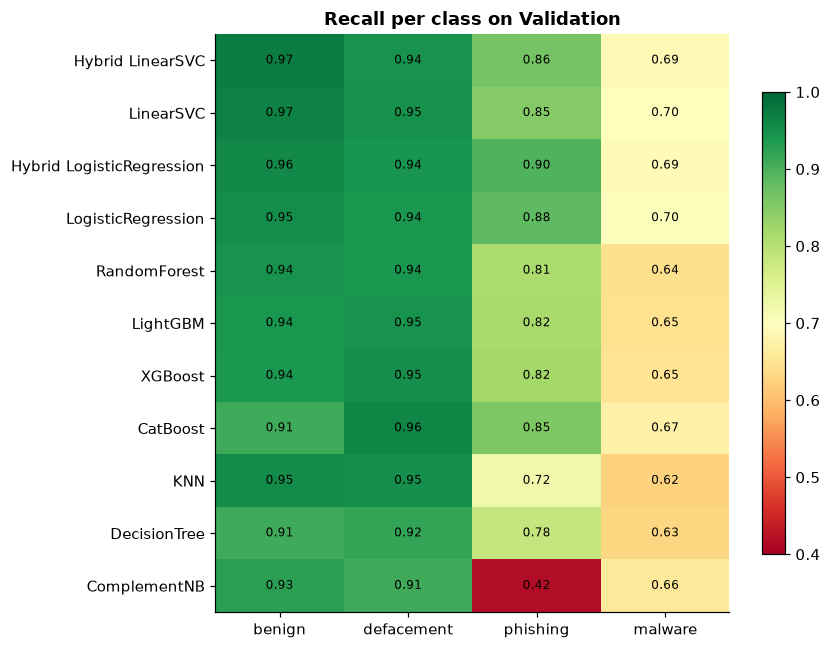

In [21]:
per_class_val = {}
for name in screening.index:
    rep = classification_report(y_val, val_pred[name], labels=LABELS, output_dict=True, zero_division=0)
    per_class_val[name] = [rep[c]["recall"] for c in LABELS]
m = pd.DataFrame(per_class_val, index=LABELS).T.loc[screening.index]

fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(m.values, cmap="RdYlGn", vmin=0.4, vmax=1, aspect="auto")
ax.set_xticks(range(4), LABELS); ax.set_yticks(range(len(m)), m.index)
for i in range(m.shape[0]):
    for j in range(m.shape[1]):
        ax.text(j, i, f"{m.values[i, j]:.2f}", ha="center", va="center", fontsize=8)
ax.set_title("Recall per class on Validation"); ax.grid(False)
fig.colorbar(im, ax=ax, shrink=0.8)
plt.tight_layout(); plt.show()

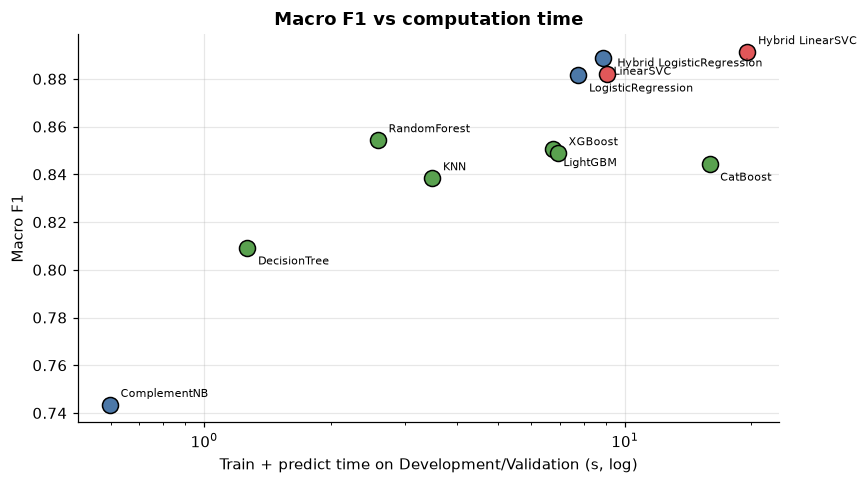

In [22]:
fig, ax = plt.subplots(figsize=(8, 4.5))
for k, (name, row) in enumerate(screening.iterrows()):
    ax.scatter(row.fit_predict_s, row.f1_macro, s=110, color=GROUP_COLORS[row.group], edgecolor="black", zorder=3)
    ax.annotate(name, (row.fit_predict_s, row.f1_macro), textcoords="offset points",
                xytext=(7, 5) if k % 2 == 0 else (7, -11), fontsize=7)
ax.set_xscale("log"); ax.set_xlabel("Train + predict time on Development/Validation (s, log)"); ax.set_ylabel("Macro F1")
ax.set_title("Macro F1 vs computation time")
plt.tight_layout(); plt.show()

**📊 ผลลัพธ์บน Validation:**
- กลุ่ม **Hybrid** และ **TF-IDF** ดีกว่ากลุ่ม **Lexical** ชัดเจน (Macro F1 0.88–0.89 เทียบกับ 0.81–0.85) แสดงว่า "ชิ้นข้อความ" ใน URL มีข้อมูลมากกว่าตัวเลขสรุปโครงสร้าง 22 ตัว
- **ผู้ชนะแต่ละกลุ่ม:** Hybrid LinearSVC (0.8913) · LinearSVC (0.8888) · Random Forest (0.8544)
- ในกลุ่ม Lexical โมเดล ensemble (Random Forest, LightGBM, XGBoost, CatBoost) ได้คะแนนใกล้กันมาก (0.844–0.854) และดีกว่า Decision Tree เดี่ยว (0.809) เพราะรวมหลาย tree ช่วยลด overfitting
- ComplementNB เร็วที่สุดแต่คะแนนต่ำที่สุด (0.744)
- Hyperparameter ที่ดีที่สุด: LinearSVC `C=1`, Logistic Regression `C=10`, KNN `k=15`, Random Forest `min_samples_leaf=3`, LightGBM `num_leaves=127`, XGBoost `max_depth=10`, CatBoost `depth=8`

## 4.4 เลือกผู้ชนะของแต่ละกลุ่ม แล้วฝึกบน Train เต็ม
นำโมเดลที่ Macro F1 บน Validation สูงสุดของแต่ละกลุ่ม (พร้อม hyperparameter ที่ดีที่สุด) ไปฝึกใหม่บน **Train เต็ม** แล้ววัดผลบน **Test**

In [23]:
winners = screening.groupby("group", sort=False).head(1)
display(winners[["group", "best_params", "f1_macro"]].rename(columns={"f1_macro": "validation_f1_macro"}))

SPEC = {name: (group, build, w) for group, name, build, _, w in CANDIDATES}
FEATS_TR, FEATS_TE = (Xtr_T, Xtr_L), (Xte_T, Xte_L)
test_rows, predictions, fitted = [], {}, {}
dummy = DummyClassifier(strategy="most_frequent").fit(np.zeros((len(y_train), 1)), y_train)
predictions["Dummy (majority)"] = dummy.predict(np.zeros((len(y_test), 1)))
test_rows.append({"model": "Dummy (majority)", "group": "Baseline", **scores(y_test, predictions["Dummy (majority)"])})
for name, row in winners.iterrows():
    group, build, w = SPEC[name]
    model = build(row.best_params)
    t0 = time.perf_counter()
    predictions[name] = fit_predict(model, make_X(group, FEATS_TR, w), y_train, make_X(group, FEATS_TE, w))
    fitted[name] = model
    test_rows.append({"model": name, "group": group, **scores(y_test, predictions[name]),
                      "validation_f1_macro": row.f1_macro, "fit_predict_s": time.perf_counter() - t0})
    print(f"✓ {name:<27} Test Macro F1 = {test_rows[-1]['f1_macro']:.4f}")
results = pd.DataFrame(test_rows).set_index("model")
results

,group,best_params,validation_f1_macro
model,,,
Hybrid LinearSVC,Hybrid,{'C': 1},0.8913
LinearSVC,TF-IDF,{'C': 1},0.8888
RandomForest,Lexical,{'min_samples_leaf': 3},0.8544


✓ Hybrid LinearSVC            Test Macro F1 = 0.9192


✓ LinearSVC                   Test Macro F1 = 0.9171


✓ RandomForest                Test Macro F1 = 0.8733


,group,accuracy,precision_macro,recall_macro,f1_macro,validation_f1_macro,fit_predict_s
model,,,,,,,
Dummy (majority),Baseline,0.6678,0.1670,0.2500,0.2002,NaN,NaN
Hybrid LinearSVC,Hybrid,0.9486,0.9279,0.9121,0.9192,0.8913,87.3971
LinearSVC,TF-IDF,0.9463,0.9257,0.9102,0.9171,0.8888,45.5713
RandomForest,Lexical,0.9073,0.8823,0.8729,0.8733,0.8544,19.8186


---
# 5. Model Evaluation

### เลือก Metric อย่างไร
| Metric | ความหมาย | ใช้ในงานนี้เพราะ |
|---|---|---|
| **Accuracy** | สัดส่วนที่ทายถูกทั้งหมด | ดูภาพรวม แต่หลอกได้เมื่อข้อมูลไม่สมดุล |
| **Precision** | ที่ทายว่าเป็นคลาส c ถูกจริงกี่ % | ถ้าต่ำ = เตือนผิด (false alarm) บ่อย |
| **Recall** | คลาส c จริง ถูกจับได้กี่ % | สำคัญที่สุดกับ phishing/malware — พลาด = ผู้ใช้โดนโจมตี |
| **F1-score** | ค่าเฉลี่ยฮาร์มอนิกของ Precision กับ Recall | สมดุลระหว่างเตือนผิดกับพลาด |
| **Macro F1** ⭐ | F1 เฉลี่ยทุกคลาสเท่า ๆ กัน | **เกณฑ์หลัก** เพราะให้คลาสเล็ก (malware) มีความสำคัญเท่าคลาสใหญ่ |
| **Confusion Matrix** | ตารางจริง vs ทาย | ดูว่าสับสนระหว่างคลาสไหน |

## 5.1 ผลของผู้ชนะแต่ละกลุ่มบน Test

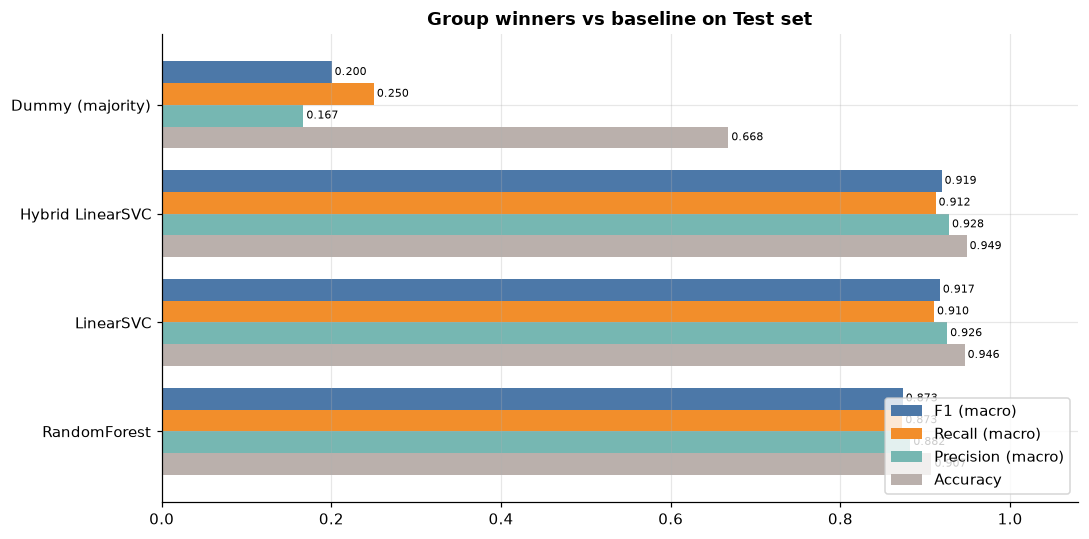

In [24]:
plot_df = results[["accuracy", "precision_macro", "recall_macro", "f1_macro"]].iloc[::-1]
ax = plot_df.plot.barh(figsize=(10, 5), width=0.8, color=["#BAB0AC", "#76B7B2", "#F28E2B", "#4C78A8"])
for c in ax.containers:
    ax.bar_label(c, fmt="%.3f", fontsize=7, padding=2)
handles, _ = ax.get_legend_handles_labels()
ax.set_xlim(0, 1.08); ax.set_title("Group winners vs baseline on Test set"); ax.set_ylabel("")
ax.legend(handles[::-1], ["F1 (macro)", "Recall (macro)", "Precision (macro)", "Accuracy"], loc="lower right")
plt.tight_layout(); plt.show()

## 5.2 Confusion Matrix ของผู้ชนะทั้ง 3 กลุ่ม

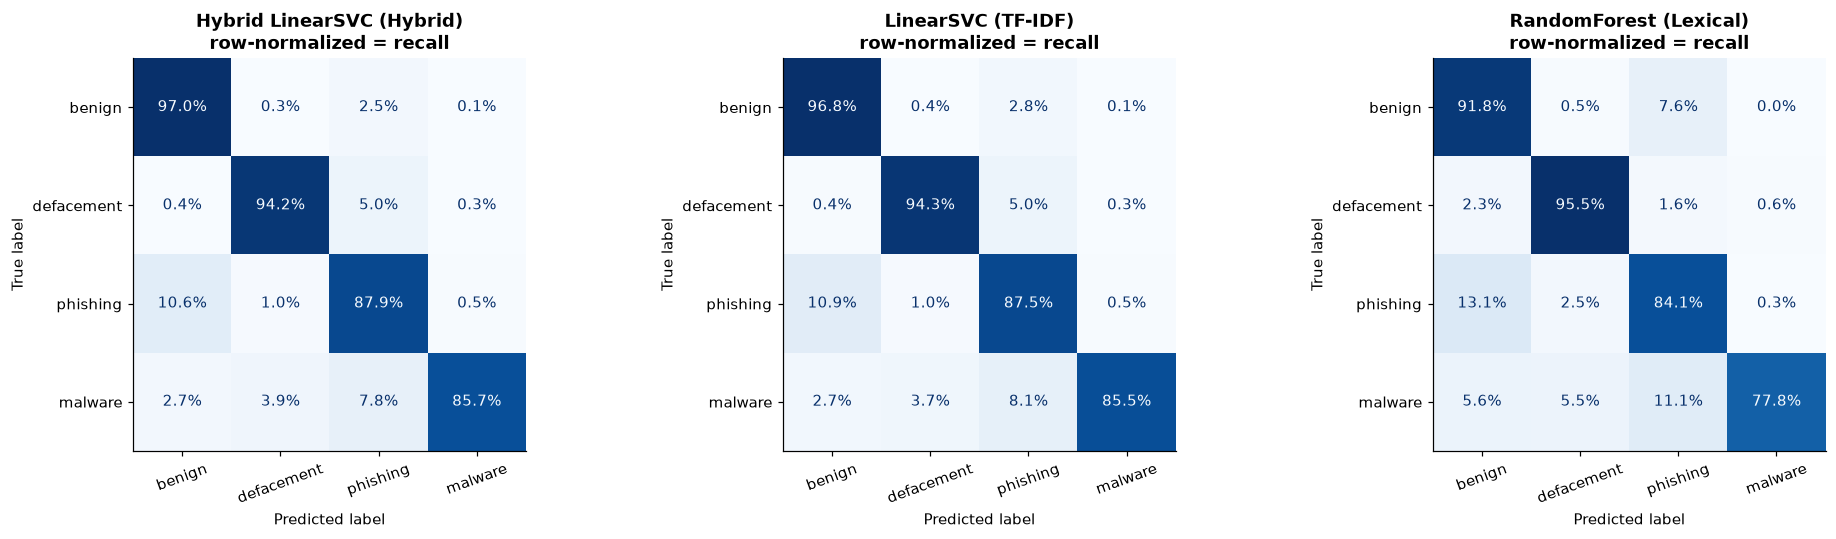

In [25]:
win_names = list(winners.index)
fig, ax = plt.subplots(1, len(win_names), figsize=(6 * len(win_names), 5))
for a, name in zip(np.atleast_1d(ax), win_names):
    cm = confusion_matrix(y_test, predictions[name], labels=LABELS, normalize="true")
    ConfusionMatrixDisplay(cm, display_labels=LABELS).plot(ax=a, cmap="Blues", values_format=".1%", colorbar=False)
    a.set_title(f"{name} ({SPEC[name][0]})\nrow-normalized = recall"); a.grid(False)
    a.tick_params(axis="x", rotation=20)
plt.tight_layout(); plt.show()

## 5.3 เลือกโมเดลสุดท้าย
เลือกผู้ชนะที่ได้ **Macro F1 บน Validation สูงสุด** (ไม่ได้เลือกจาก Test) แล้วยืนยันผลด้วย Test

In [26]:
BEST = winners.f1_macro.idxmax()
print(f"🏆 โมเดลสุดท้าย: {BEST}  (กลุ่ม {SPEC[BEST][0]}, hyperparameters {winners.loc[BEST, 'best_params']})\n")
print(f"Classification report บน Test — {BEST}")
print(classification_report(y_test, predictions[BEST], labels=LABELS, digits=4))

🏆 โมเดลสุดท้าย: Hybrid LinearSVC  (กลุ่ม Hybrid, hyperparameters {'C': 1})

Classification report บน Test — Hybrid LinearSVC


              precision    recall  f1-score   support

      benign     0.9743    0.9704    0.9724     85615
  defacement     0.9644    0.9423    0.9532     19062
    phishing     0.8249    0.8789    0.8510     18797
     malware     0.9480    0.8566    0.9000      4729

    accuracy                         0.9486    128203
   macro avg     0.9279    0.9121    0.9192    128203
weighted avg     0.9499    0.9486    0.9491    128203



**เหตุผลที่เลือก Hybrid LinearSVC เป็นโมเดลสุดท้าย**
1. **Macro F1 บน Validation สูงที่สุด (0.8913)** — เลือกโดยไม่ดู Test และเมื่อวัดบน Test ก็ยังสูงที่สุด (**Macro F1 0.9192, Accuracy 94.86%**)
2. **ดีกว่า LinearSVC ที่ใช้ TF-IDF อย่างเดียวเล็กน้อย** (Test 0.9192 vs 0.9171) — lexical features ช่วยเพิ่มได้เล็กน้อย ส่วนพลังหลักมาจาก TF-IDF
3. **ดีกว่าผู้ชนะกลุ่ม Lexical (Random Forest, 0.8733) ชัดเจน** โดยเฉพาะ recall ของ phishing
4. **เร็วและเล็ก** — ฝึกบน 512,808 URLs ในเวลาประมาณ 1 นาที ไฟล์โมเดล 1.8 MB ทำนาย 1 URL ในระดับมิลลิวินาที เหมาะกับ Web App

หมายเหตุ: คะแนนบน Test สูงกว่า Validation เพราะตอนฝึกผู้ชนะใช้ Train เต็ม 512,808 แถว ขณะที่รอบคัดกรองใช้เพียง 100,000 แถว

## 5.4 วิเคราะห์ข้อผิดพลาดของโมเดลสุดท้าย
ความผิดพลาดที่อันตรายที่สุดคือ **phishing/malware ถูกทายว่า benign** (ลิงก์อันตรายหลุดผ่าน)

In [27]:
err = test[["url", "type"]].copy(); err["prediction"] = predictions[BEST]
danger = err.type.isin(["phishing", "malware"])
summary = pd.Series({
    "phishing → benign (หลุด)": int(((err.type == "phishing") & (err.prediction == "benign")).sum()),
    "malware → benign (หลุด)": int(((err.type == "malware") & (err.prediction == "benign")).sum()),
    "benign → เตือนผิด": int(((err.type == "benign") & (err.prediction != "benign")).sum()),
    "อันตราย ถูกเตือน (ทายเป็นคลาสอันตรายใดก็ได้)": f"{(err.prediction[danger] != 'benign').mean():.2%}",
})
display(summary.to_frame("count"))
print("ตัวอย่าง phishing ที่โมเดลทายว่า benign:")
display(err[(err.type == "phishing") & (err.prediction == "benign")].sample(8, random_state=1).assign(url=lambda d: d.url.map(defang)))

,count
phishing → benign (หลุด),1988
malware → benign (หลุด),127
benign → เตือนผิด,2530
อันตราย ถูกเตือน (ทายเป็นคลาสอันตรายใดก็ได้),91.01%


ตัวอย่าง phishing ที่โมเดลทายว่า benign:


,url,type,prediction
125805,en[.]wikipedia[.]org/wiki/Open_Firmware,phishing,benign
125799,en[.]wikipedia[.]org/wiki/Operating_system,phishing,benign
123784,en[.]wikipedia[.]org/wiki/Pluggable_look_and_feel,phishing,benign
52258,dailysports[.]us,phishing,benign
120354,narvellstrickland1[.]tripod[.]com/cottonmillhi...,phishing,benign
127202,tomgale[.]com/galegames/galegames[.]htm,phishing,benign
120847,leedberg[.]com/glsoft/,phishing,benign
25714,hxxp://service[.]confirm[.]paypal[.]cmd[.]cgi[...,phishing,benign


## 5.5 บันทึกโมเดลสำหรับ Web App
รวม TF-IDF + χ² selector + lexical (22 features) + scaler + classifier ที่ฝึกแล้วเป็น **Pipeline เดียว** ที่รับ "ข้อความ URL" แล้วคืนชื่อคลาส
และตรวจว่าผลทำนายตรงกับตอนประเมิน

In [28]:
assert not isinstance(fitted[BEST], XGBClassifier), "XGBoost ต้องมีตัวแปลง label กลับก่อนบันทึกให้แอป"
tfidf_block = Pipeline([("tfidf", tfidf), ("chi2", selector)])
lexical_block = Pipeline([("extract", FunctionTransformer(extract_lexical_features, kw_args={"keep": KEEP_IDX})),
                          ("scale", scaler)])
group, _, w = SPEC[BEST]
FEATURE_STEP = {"TF-IDF": tfidf_block, "Lexical": lexical_block,
                "Hybrid": FeatureUnion([("tfidf", tfidf_block), ("lexical", lexical_block)],
                                       transformer_weights={"tfidf": 1.0, "lexical": w})}
final_model = Pipeline([("features", FEATURE_STEP[group]), ("clf", fitted[BEST])])

check = final_model.predict(X_test_text[:20_000])
assert (np.asarray(check).ravel() == predictions[BEST][:20_000]).all(), "pipeline ให้ผลต่างจากตอนประเมิน"

joblib.dump(final_model, "models/url_classifier.joblib", compress=3)
meta = {"model": BEST, "group": group, "params": winners.loc[BEST, "best_params"], "lexical_weight": w,
        "n_ngrams": int(Xtr_T.shape[1]), "lexical_keep_idx": KEEP_IDX, "lexical_features": KEPT_NAMES,
        "labels": LABELS, "train_rows": len(train), "test_rows": len(test),
        "test_scores": results.loc[BEST, ["accuracy", "precision_macro", "recall_macro", "f1_macro"]].astype(float).round(4).to_dict(),
        "validation_screening": screening["f1_macro"].round(4).to_dict()}
Path("models/model_info.json").write_text(json.dumps(meta, ensure_ascii=False, indent=2, default=str), encoding="utf-8")
print(f"บันทึก models/url_classifier.joblib ({Path('models/url_classifier.joblib').stat().st_size/1e6:.1f} MB)")

# ทดสอบโหลดกลับและทำนายเหมือนที่ Web App ทำ
loaded = joblib.load("models/url_classifier.joblib")
demo = ["en.wikipedia.org/wiki/Machine_learning", "http://paypal.com.secure-login.verify-account.xyz/signin?id=123",
        "http://192.168.10.5/files/setup.exe", "http://example.com/index.php?option=com_content&view=article&id=5"]
pd.DataFrame({"url": [defang(u) for u in demo], "prediction": loaded.predict(np.array(demo, dtype=object))})

บันทึก models/url_classifier.joblib (1.8 MB)


,url,prediction
0,en[.]wikipedia[.]org/wiki/Machine_learning,benign
1,hxxp://paypal[.]com[.]secure-login[.]verify-ac...,phishing
2,hxxp://192[.]168[.]10[.]5/files/setup[.]exe,malware
3,hxxp://example[.]com/index[.]php?option=com_co...,defacement


## 5.6 ทดสอบกับ URL จริงที่รู้จัก (Sanity check)
คะแนนบน Test สูง แต่ Test มาจากแหล่งเดียวกับ Train จึงลองป้อน URL ที่รู้คำตอบ และเขียน URL เดียวกันหลายรูปแบบ

In [29]:
known = ["en.wikipedia.org/wiki/Machine_learning", "https://en.wikipedia.org/wiki/Machine_learning",
         "google.com/search?q=weather", "google.com", "https://www.google.com/",
         "youtube.com/watch?v=dQw4w9WgXcQ", "github.com/scikit-learn/scikit-learn",
         "paypal.com.secure-login.verify-account.xyz/signin?id=123", "http://192.168.10.5/files/setup.exe"]
expected = ["benign"] * 7 + ["phishing", "malware"]
sanity = pd.DataFrame({"url": [defang(u) for u in known], "expected": expected,
                       "prediction": final_model.predict(np.array(known, dtype=object))})
sanity["correct"] = np.where(sanity.expected == sanity.prediction, "✅", "❌")
sanity

,url,expected,prediction,correct
0,en[.]wikipedia[.]org/wiki/Machine_learning,benign,benign,✅
1,hxxps://en[.]wikipedia[.]org/wiki/Machine_lear...,benign,phishing,❌
2,google[.]com/search?q=weather,benign,benign,✅
3,google[.]com,benign,phishing,❌
4,hxxps://www[.]google[.]com/,benign,phishing,❌
5,youtube[.]com/watch?v=dQw4w9WgXcQ,benign,benign,✅
6,github[.]com/scikit-learn/scikit-learn,benign,benign,✅
7,paypal[.]com[.]secure-login[.]verify-account[....,phishing,phishing,✅
8,hxxp://192[.]168[.]10[.]5/files/setup[.]exe,malware,malware,✅


**📊 ผลลัพธ์ (ข้อจำกัดสำคัญ):** ลิงก์อันตรายตัวอย่างถูกจับได้ และ URL ปกติที่มี path (Wikipedia, Google search, YouTube, GitHub) ทายถูก
แต่ **URL ปกติบางรูปแบบถูกทายเป็น phishing**
- `en.wikipedia.org/wiki/...` → benign ✅ แต่ **เติม `https://` เข้าไปอย่างเดียว** กลายเป็น phishing ❌
- หน้าแรกสั้น ๆ เช่น `google.com`, `https://www.google.com/` → phishing ❌ เพราะใน Dataset URL phishing จำนวนมากเป็นโดเมนสั้น ๆ ส่วน benign เกือบทั้งหมดเป็น URL ยาวที่มี path

สาเหตุคือ **dataset bias** ที่พบในหัวข้อ 3.4 — รูปแบบการเขียน URL ผูกกับแหล่งที่เก็บข้อมูลของแต่ละคลาส
เราทดลองแก้โดยตัด `http(s)://`, `www.` และ `/` ท้าย URL ออกก่อนฝึก (normalize) แต่ Macro F1 ลดลงเหลือ ~0.85
และ `google.com` ก็ยังถูกทายเป็น phishing จึง **คงวิธีเดิมไว้** และรายงานข้อจำกัดนี้ในหัวข้อ Discussion

## 5.7 N-grams ที่มีผลต่อการทำนายมากที่สุด (ตีความโมเดล)

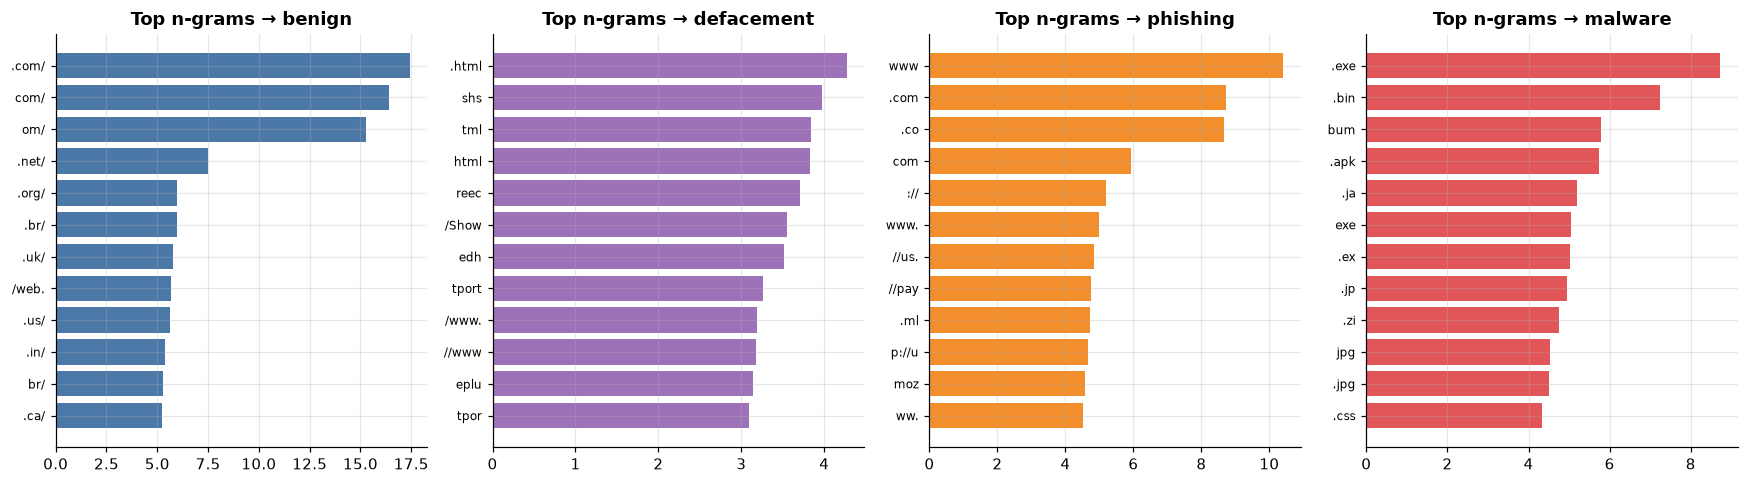

In [30]:
clf = fitted[BEST]
if hasattr(clf, "coef_") and group in ("TF-IDF", "Hybrid"):
    vocab = vocab_all[selector.get_support()]
    fig, axes = plt.subplots(1, 4, figsize=(16, 4.5))
    for a, cls in zip(axes, LABELS):
        coef = clf.coef_[list(clf.classes_).index(cls), :len(vocab)]
        top = np.argsort(coef)[-12:]
        a.barh([repr(v)[1:-1] for v in vocab[top]], coef[top], color=COLORS[cls])
        a.set_title(f"Top n-grams → {cls}"); a.tick_params(axis="y", labelsize=8)
    plt.tight_layout(); plt.show()
else:
    print("โมเดลสุดท้ายไม่ใช่โมเดลเชิงเส้นบน TF-IDF จึงไม่มี n-gram coefficients ให้แสดง")

**📊 ผลลัพธ์:** บางรูปแบบสมเหตุสมผล เช่น malware ↔ นามสกุลไฟล์ `.exe`, `.bin`, `.apk`; phishing ↔ `//pay` (paypal ปลอม); defacement ↔ `.html`
แต่ n-gram ที่มีน้ำหนักสูงหลายตัว **ยืนยัน dataset bias** จากหัวข้อ 3.4 และ 5.6: `www` เป็นสัญญาณอันดับ 1 ของ phishing, `//www` เป็นสัญญาณของ defacement
และ `.com/` เป็นสัญญาณของ benign — เป็นเรื่องรูปแบบการเขียน URL ไม่ใช่ความอันตรายจริง

---
# 6. Web Application

พัฒนา Web App **1 หน้า** ด้วย **Streamlit** (ไฟล์ `app.py`) ใช้โมเดล `models/url_classifier.joblib` ที่บันทึกด้านบน

| องค์ประกอบที่โจทย์กำหนด | ในแอป |
|---|---|
| ช่องกรอกข้อมูล | ช่องกรอก URL + ปุ่มตัวอย่าง URL |
| ปุ่ม Predict | ปุ่ม **🔍 Predict** |
| แสดงผลลัพธ์การทำนาย | การ์ดผลลัพธ์แสดงคลาสพร้อมสีตามระดับความเสี่ยง |
| แสดงความหมายของผลลัพธ์ | คำอธิบายของคลาส + คำแนะนำว่าควรทำอย่างไร + กราฟคะแนนของแต่ละคลาส |

**ขั้นตอนการทำงาน:** ผู้ใช้กรอก URL → ตรวจ input (ว่าง/control characters) → Pipeline แปลงเป็น TF-IDF + lexical features → LinearSVC ทำนาย → แสดงผล
แอป **ไม่เปิดเว็บไซต์ที่กรอก** จึงปลอดภัยต่อการทดสอบลิงก์อันตราย

**วิธีรัน**
```bash
pip install -r requirements.txt
streamlit run app.py
```

---
# 7. Discussion

### ✅ จุดเด่นของโมเดล
- **Accuracy 94.86% / Macro F1 0.919** บน Test 128,203 URLs ที่ **แยก hostname** จาก Train (ไม่ใช่การสุ่มธรรมดาที่ทำให้คะแนนสูงเกินจริง)
- **เลือกโมเดลอย่างเป็นธรรม** — คัดเลือก 11 โมเดลและ hyperparameters บน Validation ที่แยกจาก Test แล้วใช้ Test วัดผลครั้งเดียว
- ลิงก์อันตรายจริง (phishing + malware) **ถูกเตือน 91.0%**, defacement F1 0.95 และ benign ถูกเตือนผิดเพียง 3.0%
- ดีกว่า Baseline (Dummy, Macro F1 0.20) และดีกว่าอีก 10 โมเดลที่เปรียบเทียบ
- ใช้เพียงข้อความ URL → **เร็ว ปลอดภัย** ไม่ต้องเปิดเว็บไซต์; โมเดลเล็ก 1.8 MB ทำนาย 1 URL ในระดับมิลลิวินาที
- Feature Selection ลด TF-IDF จาก 50,000 เหลือ 20,000 n-grams และ lexical จาก 27 เหลือ 22 ตัว ทำให้โมเดลเล็กลง
- โมเดลเชิงเส้น **ตีความได้** จาก n-grams ที่มีน้ำหนักสูง (หัวข้อ 5.7)

### ⚠️ จุดอ่อน
- **Dataset bias / shortcut learning** — โมเดลใช้ "รูปแบบการเขียน URL" (มี `http://`, `www.` หรือไม่) เป็นสัญญาณสำคัญ ซึ่งผูกกับแหล่งเก็บข้อมูล ไม่ใช่ความอันตรายจริง
  ทำให้ URL ปกติบางรูปแบบ เช่น `https://www.google.com/` ถูกทายเป็น phishing (หัวข้อ 5.6) — **ความแม่นยำกับ URL ทั่วไปในชีวิตจริงจึงต่ำกว่าคะแนนบน Test**
- **Phishing ยากที่สุด** — Precision 0.82 / Recall 0.88; phishing 1,988 URL หลุดเป็น benign
- Malware recall 0.857 — มี malware 127 URL ที่หลุดเป็น benign
- **Label noise** — Dataset มี label ที่น่าสงสัย เช่น หน้า Wikipedia ถูกติด label phishing (ตัวอย่างในหัวข้อ 5.4) ทำให้คะแนนส่วนหนึ่งผิดเพราะ label ไม่ใช่เพราะโมเดล
- LinearSVC **ไม่ให้ค่าความน่าจะเป็น** — คะแนนที่แสดงในแอปเป็น decision score ใช้เปรียบเทียบระหว่างคลาสได้ แต่ไม่ใช่ % ความมั่นใจ
- ดูเฉพาะข้อความ ไม่ได้ดูเนื้อหาเว็บ อายุโดเมน หรือ SSL certificate

### 🧩 ปัญหาที่พบระหว่างทำโครงงาน
1. **ข้อมูลซ้ำและ label ขัดแย้ง** — แถวซ้ำ 10,066 แถว และ URL เดียวกันมีหลาย label (เช่น หน้า Wikipedia ถูกติดทั้ง benign และ phishing) ต้องทำความสะอาดก่อน
2. **Data leakage จาก hostname** — ถ้าสุ่มแบ่งธรรมดา URL จากเว็บเดียวกันอยู่ทั้ง Train/Test จึงเปลี่ยนมาใช้ StratifiedGroupKFold ตาม hostname
3. **ข้อมูลไม่สมดุล** — malware มีเพียง ~5% จึงใช้ class_weight และวัดด้วย Macro F1
4. **ขนาดข้อมูลใหญ่** — การคัดเลือก 11 โมเดล × หลาย hyperparameters บนข้อมูลเต็มใช้เวลานาน จึงคัดกรองบน Development Train 100,000 แถว แล้วค่อยฝึกผู้ชนะบน Train เต็ม;
   โมเดล tree/KNN ไม่เหมาะกับ TF-IDF มิติสูง จึงใช้กับ lexical features
5. **Dataset bias** — พบตอนทดสอบกับ URL จริง (หัวข้อ 5.6) ทดลองแก้ด้วยการ normalize URL แต่ Macro F1 ลดเหลือ ~0.85 และยังไม่แก้ปัญหาหน้าแรกของเว็บ
   แสดงว่าต้องแก้ที่ **ข้อมูล** มากกว่าที่โมเดล

### 🚀 แนวทางพัฒนาในอนาคต
- **เพิ่มข้อมูล benign ที่หลากหลาย** (เช่น หน้าแรกของเว็บยอดนิยม ทั้งแบบมีและไม่มี `https://www.`) และรวม Dataset จากหลายแหล่ง/หลายช่วงเวลา เพื่อลด bias
- ทำ **probability calibration** (`CalibratedClassifierCV`) เพื่อแสดง % ความมั่นใจ และปรับ threshold ให้จับ phishing ได้มากขึ้น
- เพิ่ม features ที่ไม่ใช่ข้อความ เช่น อายุโดเมน, WHOIS, SSL certificate, อันดับความนิยมของโดเมน
- ทดสอบกับ Dataset ภายนอก (เช่น PhishTank ล่าสุด) เพื่อวัดความสามารถกับข้อมูลใหม่จริง

---
# 8. References
1. Siddhartha, M. *Malicious URLs Dataset*. Kaggle. https://www.kaggle.com/datasets/sid321axn/malicious-urls-dataset
2. Mamun, M. S. I., et al. (2016). *Detecting Malicious URLs Using Lexical Analysis*. NSS 2016 (ISCX-URL2016). https://www.unb.ca/cic/datasets/url-2016.html
3. Pedregosa, F., et al. (2011). *Scikit-learn: Machine Learning in Python*. JMLR 12, 2825–2830. https://scikit-learn.org
4. scikit-learn documentation — [TfidfVectorizer](https://scikit-learn.org/stable/modules/generated/sklearn.feature_extraction.text.TfidfVectorizer.html), [LinearSVC](https://scikit-learn.org/stable/modules/generated/sklearn.svm.LinearSVC.html), [StratifiedGroupKFold](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.StratifiedGroupKFold.html), [Classification metrics](https://scikit-learn.org/stable/modules/model_evaluation.html#classification-metrics)
5. Chen, T., & Guestrin, C. (2016). *XGBoost: A Scalable Tree Boosting System*. KDD 2016. · Ke, G., et al. (2017). *LightGBM*. NeurIPS 2017. · Prokhorenkova, L., et al. (2018). *CatBoost*. NeurIPS 2018.
6. Streamlit documentation. https://docs.streamlit.io
6. PhishTank. https://phishtank.org